# Hypothesis Testing: Cardiovascular Risk <hr style = "border:2.5px solid #e22424ff"> </hr>

<b>Amelo Jerow A.</b>
<br>T09 - A</br>

In [1]:
# imports and packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.power import TTestPower

In [2]:
# load dataset
df = pd.read_csv(r"dataset\heart_attack_dataset.csv",
                 delimiter=",")
df

,Gender,Age,Blood Pressure (mmHg),Cholesterol (mg/dL),Has Diabetes,Smoking Status,Chest Pain Type,Treatment
0,Male,70,181,262,No,Never,Typical Angina,Lifestyle Changes
1,Female,55,103,253,Yes,Never,Atypical Angina,Angioplasty
2,Male,42,95,295,Yes,Current,Typical Angina,Angioplasty
3,Male,84,106,270,No,Never,Atypical Angina,Coronary Artery Bypass Graft (CABG)
4,Male,86,187,296,Yes,Current,Non-anginal Pain,Medication
...,...,...,...,...,...,...,...,...
995,Male,42,125,193,Yes,Current,Typical Angina,Angioplasty
996,Male,80,186,267,Yes,Never,Atypical Angina,Coronary Artery Bypass Graft (CABG)
997,Female,64,108,174,Yes,Current,Non-anginal Pain,Coronary Artery Bypass Graft (CABG)
998,Female,84,123,195,No,Current,Asymptomatic,Lifestyle Changes


In [3]:
# summary of dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Gender                 1000 non-null   object
 1   Age                    1000 non-null   int64 
 2   Blood Pressure (mmHg)  1000 non-null   int64 
 3   Cholesterol (mg/dL)    1000 non-null   int64 
 4   Has Diabetes           1000 non-null   object
 5   Smoking Status         1000 non-null   object
 6   Chest Pain Type        1000 non-null   object
 7   Treatment              1000 non-null   object
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [4]:
# summary of statistics
df.describe()

,Age,Blood Pressure (mmHg),Cholesterol (mg/dL)
count,1000.000000,1000.000000,1000.000000
mean,60.338000,145.440000,223.789000
std,17.317496,31.756525,42.787817
min,30.000000,90.000000,150.000000
25%,45.000000,118.000000,185.000000
50%,60.500000,146.000000,225.500000
75%,76.000000,173.000000,259.000000
max,89.000000,199.000000,299.000000


# Data Outliers Visualization

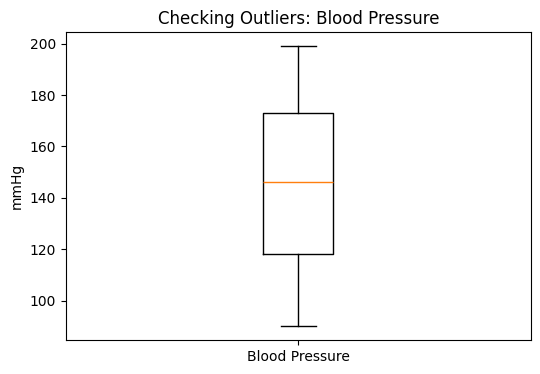

In [5]:
# plotting blood Pressure
plt.figure(figsize=(6, 4))
plt.boxplot(df['Blood Pressure (mmHg)'], tick_labels=['Blood Pressure'])
plt.title("Checking Outliers: Blood Pressure")
plt.ylabel("mmHg")
plt.show()

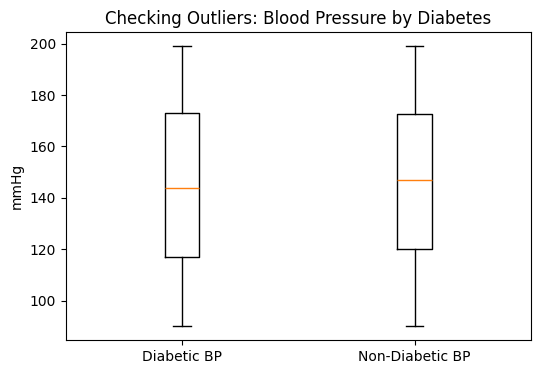

In [6]:
# plotting blood pressure by Diabetes Status
diabetic_bp_raw = df[df['Has Diabetes'] == 'Yes']['Blood Pressure (mmHg)']
nondiabetic_bp_raw = df[df['Has Diabetes'] == 'No']['Blood Pressure (mmHg)']

plt.figure(figsize=(6, 4))
plt.boxplot([diabetic_bp_raw, nondiabetic_bp_raw], tick_labels=['Diabetic BP', 'Non-Diabetic BP'])
plt.title("Checking Outliers: Blood Pressure by Diabetes")
plt.ylabel("mmHg")
plt.show()

# Data Cleaning (FOR FORMALITY ONLY SIR KAY WAY NAMAN OUTLIERS AKON DATASET)

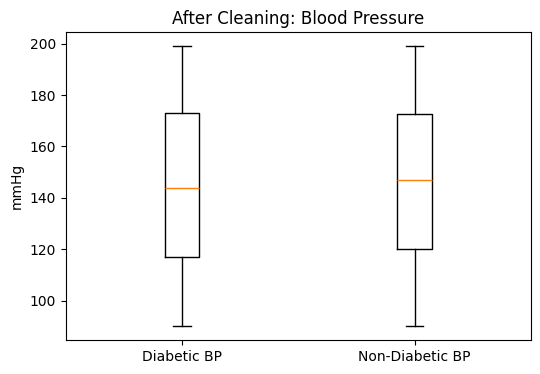

In [7]:
# removing blood pressure outliers
z_bp = stats.zscore(df['Blood Pressure (mmHg)'])
bp_outliers = (z_bp < -3) | (z_bp > 3)
df = df[~bp_outliers]

# re-plot clean Blood Pressure
diabetic_bp_clean = df[df['Has Diabetes'] == 'Yes']['Blood Pressure (mmHg)']
nondiabetic_bp_clean = df[df['Has Diabetes'] == 'No']['Blood Pressure (mmHg)']

plt.figure(figsize=(6, 4))
plt.boxplot([diabetic_bp_clean, nondiabetic_bp_clean], tick_labels=['Diabetic BP', 'Non-Diabetic BP'])
plt.title("After Cleaning: Blood Pressure")
plt.ylabel("mmHg")
plt.show()

In [8]:
print(f"Dataset size after removing outliers: {df.shape[0]} rows")  

Dataset size after removing outliers: 1000 rows


# NORMALIZATION (Central Limit Theorem)

In [9]:
np.random.seed(42)
n_samples = 100
sample_size = 30

bp_means, diabetic_bp_means, nondiabetic_bp_means = [], [], []

for _ in range(n_samples):
    bp_means.append(df['Blood Pressure (mmHg)'].sample(sample_size, replace=True).mean())
    diabetic_bp_means.append(df[df['Has Diabetes'] == 'Yes']['Blood Pressure (mmHg)'].sample(sample_size, replace=True).mean())
    nondiabetic_bp_means.append(df[df['Has Diabetes'] == 'No']['Blood Pressure (mmHg)'].sample(sample_size, replace=True).mean())

In [10]:
# normalized dataframe of the sample means
clt_df = pd.DataFrame({
    'BP_Means': bp_means,
    'Diabetic_BP': diabetic_bp_means,
    'NonDiabetic_BP': nondiabetic_bp_means
})

print(clt_df.describe())

         BP_Means  Diabetic_BP  NonDiabetic_BP
count  100.000000   100.000000      100.000000
mean   144.894000   145.238667      146.273667
std      5.679531     5.608341        5.707746
min    133.633333   131.466667      131.200000
25%    140.416667   141.483333      142.633333
50%    144.350000   145.200000      146.650000
75%    148.608333   149.183333      149.400000
max    158.933333   156.566667      161.366667


# 1-SAMPLE T-TEST

In [11]:
"""
right-tailed test
------------------
Ho: u_bp = 120
Ha: u_bp > 120 
"""
#standard healthy blood pressure
pop_mean = 120

# bpmeans from our CLT-normalized dataframe
t_test, p_value = stats.ttest_1samp(clt_df['BP_Means'], pop_mean,
                                    alternative='greater')

print(f"t statistic: {t_test:.4f}")
print(f"P-value: {p_value:.4f}")

# verdict
alpha = 0.05
if p_value < alpha:
    # reject null hypothesis
    print("The average Blood Pressure significantly exceeds the 120 mmHg health standard.")
else:
    # fail to reject null hypothesis
    print("The average Blood Pressure meets the 120 mmHg health standard.")

t statistic: 43.8311
P-value: 0.0000
The average Blood Pressure significantly exceeds the 120 mmHg health standard.


In [12]:
# cohen's d
# For 1-sample, we compare the sample mean to the population mean
sample_mean = clt_df['BP_Means'].mean()
sample_std = clt_df['BP_Means'].std(ddof=1)
pop_mean = 120

d = abs((sample_mean - pop_mean) / sample_std)

print(f"Cohen's d: {d:.4f}")

# power of a test
power = TTestPower().power(
    effect_size = d, 
    nobs = clt_df['BP_Means'].count(),
    alpha = 0.05,
    alternative = "larger"
)

print(f"Power of the test: {power*100:.2f}%")

Cohen's d: 4.3831
Power of the test: 100.00%


# 2-Sample t-Test

## Normality proof between Diabetic and Non-Diabetic Cholesterol

In [13]:
print("Diabetic Blood Pressure:")
w_stat_d, p_d = stats.shapiro(clt_df['Diabetic_BP'])
print(f"w_stat: {w_stat_d:.4f}")
print(f"P-value: {p_d:.4f}")

# verdict
alpha = 0.05
if p_d < alpha:
    # reject null hypothesis
    print("Non-normal data")
else:
    # fail to reject null hypothesis
    print("Normal data")

print("\nNon-Diabetic Blood Pressure:")
w_stat_nd, p_nd = stats.shapiro(clt_df['NonDiabetic_BP'])
print(f"w_stat: {w_stat_nd:.4f}")
print(f"P-value: {p_nd:.4f}")

# verdict
if p_nd < alpha:
    # reject null hypothesis
    print("Non-normal data")
else:
    # fail to reject null hypothesis
    print("Normal data")

Diabetic Blood Pressure:
w_stat: 0.9896
P-value: 0.6307
Normal data

Non-Diabetic Blood Pressure:
w_stat: 0.9950
P-value: 0.9757
Normal data


In [14]:
"""
F-Test for equality of variances
--------------------------------
Ho: var_diabetic = var_nondiabetic
Ha: var_diabetic != var_nondiabetic
"""

var_d = clt_df['Diabetic_BP'].var(ddof=1)
var_nd = clt_df['NonDiabetic_BP'].var(ddof=1)

# Manual F-stat calculation
if var_d > var_nd:
    f_stat = var_d / var_nd
else:
    f_stat = var_nd / var_d

print(f'F-statistic = {f_stat:.4f}')

# Degrees of Freedom
dof_d = clt_df['Diabetic_BP'].count() - 1
dof_nd = clt_df['NonDiabetic_BP'].count() - 1

# probability value
p_val_f = 1 - stats.f.cdf(f_stat, dof_d, dof_nd)
print(f'p-value = {p_val_f:.4f}')

# verdict
alpha = 0.05
if p_val_f < alpha:
    # reject null hypothesis
    print("unequal variances")
    use_eq_var = False
else:
    # fail to reject null hypothesis
    print("equal variances")
    use_eq_var = True

F-statistic = 1.0358
p-value = 0.4308
equal variances


In [15]:
"""
2- Sample T-Test for Independent Samples
----------------------------------------
Ho: Diabetic_BP <= NonDiabetic_BP
Ha: Diabetic_BP > NonDiabetic_BP
"""

t_stat2, p_value2 = stats.ttest_ind(clt_df['Diabetic_BP'], clt_df['NonDiabetic_BP'], 
                                   alternative='greater', equal_var=use_eq_var)

print(f't_stat = {t_stat2:.4f}')
print(f'p_value = {p_value2:.4f}')

# verdict
alpha = 0.05
if p_value2 < alpha:
    # reject null hypothesis
    print("Blood pressure in diabetic patients is significantly higher than in non-diabetic patients.")
else:
    # fail to reject null hypothesis
    print("No significant difference in blood pressure between diabetic and non-diabetic patients.")

t_stat = -1.2934
p_value = 0.9013
No significant difference in blood pressure between diabetic and non-diabetic patients.


In [16]:
"""
Effect Size and Power
------------------
Ho: u_diabetic = u_nondiabetic
Ha: u_diabetic > u_nondiabetic
"""

# Manual Cohen's d formula
d_mean = clt_df['Diabetic_BP'].mean()
nd_mean = clt_df['NonDiabetic_BP'].mean()
d_std = clt_df['Diabetic_BP'].std(ddof=1)

d = abs((d_mean - nd_mean) / d_std)
print(f"Cohen's d: {d:.4f}")

# power of a test
power = TTestPower().power(
    effect_size = d, 
    nobs = clt_df['Diabetic_BP'].count(),
    alpha = 0.05,
    alternative = "larger"
)

print(f"Power of the test: {power*100:.2f}%")

Cohen's d: 0.1845
Power of the test: 57.46%
